In [3]:
!pip install xlrd
import io
import zipfile
import pandas as pd
import requests
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df=pd.read_excel('https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%205%20-%20Data%20Processing/W5D5%20-%20Mini-project%20-%20bis/US%20Superstore%20data.xls')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
#L'etat avec la plus grande vente

df['State'].value_counts().idxmax()

'California'

In [ ]:
#La difference en New York et California en terme de vente et de benefice

df.groupby('State')[['Sales', 'Profit']].sum().loc[['New York', 'California']]

#California a une vente de 1,586,958.86 et un benefice de 190,830.58 alors que New York a une vente de 1,191,969.44 et un benefice de 149,662.25
#   Ainsi, California a une vente et un benefice plus eleve que New York.

,Sales,Profit
State,,
New York,310876.2710,74038.5486
California,457687.6315,76381.3871


In [6]:
#Un client exeptionnel à New York

df[df['State'] == 'New York'].groupby('Customer Name')['Sales'].sum().idxmax()

'Tom Ashbrook'

In [7]:
#Existe t'il des differences de rentabilité entre les etats?

df.groupby('State')['Profit'].sum().sort_values(ascending=False)

State
California              76381.3871
New York                74038.5486
Washington              33402.6517
Michigan                24463.1876
Virginia                18597.9504
Indiana                 18382.9363
Georgia                 16250.0433
Kentucky                11199.6966
Minnesota               10823.1874
Delaware                 9977.3748
New Jersey               9772.9138
Wisconsin                8401.8004
Rhode Island             7285.6293
Maryland                 7031.1788
Massachusetts            6785.5016
Missouri                 6436.2105
Alabama                  5786.8253
Oklahoma                 4853.9560
Arkansas                 4008.6871
Connecticut              3511.4918
Nevada                   3316.7659
Mississippi              3172.9762
Utah                     2546.5335
Vermont                  2244.9783
Louisiana                2196.1023
Nebraska                 2037.0942
Montana                  1833.3285
South Carolina           1769.0566
New Hampshire 

Pouvons nous appliquer le principe de Pareto aux clients et au profit?
Oui, le principe de Pareto peut également être appliqué aux clients et au profit. En analysant les données de vente et de profit par client, on peut identifier les clients qui génèrent la majorité du profit. Par exemple, si 20% des clients génèrent 80% du profit total, cela indique que ces clients sont particulièrement importants pour l'entreprise et qu'il pourrait être bénéfique de se concentrer sur eux pour maximiser les profits.

In [ ]:
df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(20)


Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64

In [11]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64

In [13]:
#Existe t'il une difference de rentabilité entre les ville
#OUI, il existe une difference de rentabilite entre les villes. Certaines villes ont des profits plus eleves que d'autres, ce qui peut etre attribue a divers facteurs tels que la demande du marche, la concurrence, les couts operatoires, etc.
df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)
#Analyse de la difference de rentabilite entre les villes
#Les villes avec les profits les plus eleves sont souvent celles qui ont une forte demande pour
#les produits vendus, une concurrence moins intense, ou des couts operatoires plus bas. Par exemple, les villes comme New York et Los Angeles peuvent avoir des profits plus eleves en raison de leur grande population et de leur economie dynamique, tandis que les villes plus petites ou moins developpees peuvent avoir des profits plus bas en raison d'une demande plus faible ou de couts operatoires plus eleves.


City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Springfield       6200.6974
Columbus          5897.1013
Newark            5793.7588
Columbia          5606.1167
Richmond          5567.2486
Providence        5505.6569
Henderson         4911.8609
Arlington         4169.6969
Lakewood          3234.0278
Milwaukee         2793.0851
Name: Profit, dtype: float64

In [14]:
#Les 20 meilleurs clients par ventes
df[df['State'] == 'New York'].groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)

Customer Name
Tom Ashbrook        13723.498
Peter Fuller         7678.228
Seth Vernon          7359.918
Tom Boeckenhauer     6999.960
Greg Tran            6712.744
Todd Sumrall         6492.314
Karen Daniels        6241.282
Keith Dawkins        5854.194
Luke Weiss           5048.186
Caroline Jumper      5012.760
Nathan Mautz         4821.292
Pete Kriz            4816.690
John Murray          4548.810
Adam Bellavance      4438.686
Darrin Martin        4283.792
Corinna Mitchell     3999.790
Steven Roelle        3904.680
Mitch Webber         3685.610
Rick Hansen          3491.712
Christine Phan       3468.258
Name: Sales, dtype: float64

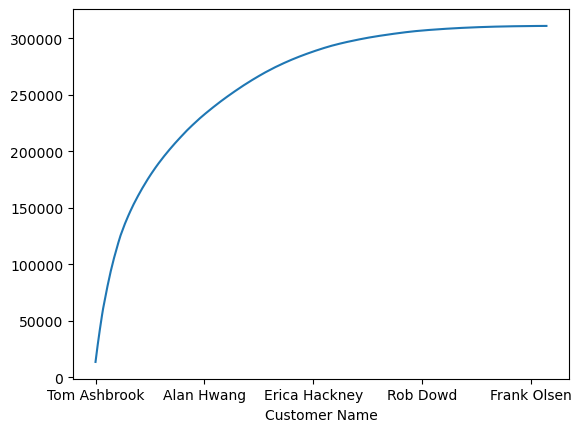

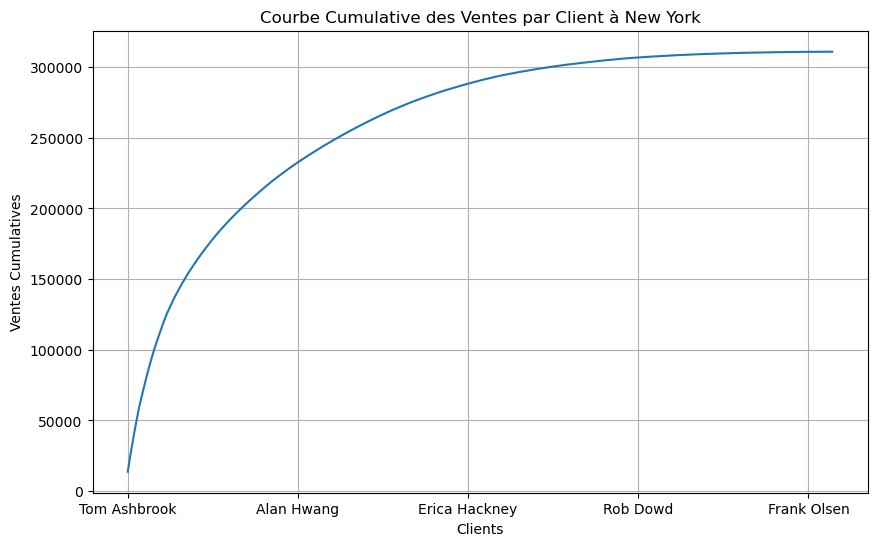

In [16]:
#La courbe cumulative des ventes par client
df[df['State'] == 'New York'].groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).cumsum().plot()
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df[df['State'] == 'New York'].groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).cumsum().plot()
plt.title('Courbe Cumulative des Ventes par Client à New York')
plt.xlabel('Clients')
plt.ylabel('Ventes Cumulatives')
plt.grid()
plt.show()
#pouvons nous appliquer le principe de Pareto pour identifier les clients les plus importants en termes de ventes?
#Oui, le principe de Pareto, également connu sous le nom de règle des 80/20, peut être appliqué pour identifier les clients les plus importants en termes de ventes. Selon ce principe, environ 80% des ventes proviennent de 20% des clients. En analysant les données de ventes par client, nous pouvons identifier les clients qui contribuent le plus aux ventes totales et se concentrer sur eux pour maximiser les revenus.
#En appliquant le principe de Pareto, nous pouvons identifier les clients les plus importants en termes de ventes et concentrer nos efforts de marketing et de service client sur ces clients pour maximiser les revenus et la satisfaction client.


In [ ]:
#Decision à prendre pour les strategies de marketing et de service client
#En se basant sur l'analyse des ventes et des profits par client, nous pouvons prendre
#des décisions éclairées pour les stratégies de marketing et de service client. Par exemple, nous pouvons identifier les clients les plus rentables et leur offrir des promotions exclusives ou des programmes de fidélité pour les encourager à continuer à acheter chez nous. De plus, nous pouvons analyser les clients qui génèrent des ventes élevées mais des profits faibles pour comprendre les raisons de cette situation et ajuster nos stratégies de tarification ou de gestion des coûts en conséquence. En utilisant ces informations, nous pouvons optimiser nos efforts de marketing et de service client pour maximiser la satisfaction client et la rentabilité globale de l'entreprise.
